In [2]:
import numpy as np
import pandas as pd
from io import StringIO
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import matplotlib as mpl
from matplotlib import colors
from scipy.optimize import curve_fit, leastsq
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from astropy.time import Time
from typing import Union, List

import frb_functions

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

In [3]:
# --- Define global colors per telescope ---
telescope_colors = {
    "Westerbork": "#1b9e77",
    "Onsala": "#d95f02",
    "Torun": "#7570b3"
}

In [4]:
def mle_constant(dm, dm_errs):
    w = 1 / np.power(dm_errs, 2)
    m = np.sum(w * dm) / np.sum(w)
    return m

,MJD,DM,DM_err,Telescope,project,burst_id,is_pband
1,60380.27609,528.085,0.508,Onsala,p47024_8,B57-o8,False
8,60380.43194,527.830,0.102,Torun,rn1l10_11,b60-tr,False
0,60380.45214,528.146,0.160,Onsala,p47024_24,B63-o8,False
2,60383.26844,528.205,0.260,Onsala,p47027_10,B102-o8,False
12,60386.37677,527.854,0.075,Westerbork,p47030_21,B105-wb,True
3,60431.43777,528.007,0.240,Onsala,p47064_38,B125-o8,False
4,60573.92099,528.313,0.103,Westerbork,p55084_34,B135-wb,False
5,60581.87250,528.464,0.086,Westerbork,p55092_32,b136-wb,False
6,60586.95299,528.468,0.081,Westerbork,p55097_41,B137-wb-Stroop,False
7,60673.60990,528.761,0.406,Westerbork,p55173_40,B140-wb,False


Slope = 3.0212e-03 ± 1.8379e-04 pc cm^-3 / day
Slope = 1.1035e+00 ± 6.7129e-02 pc cm^-3 / year
Delta DM over 318 days = 0.9607 ± 0.0584 pc cm^-3


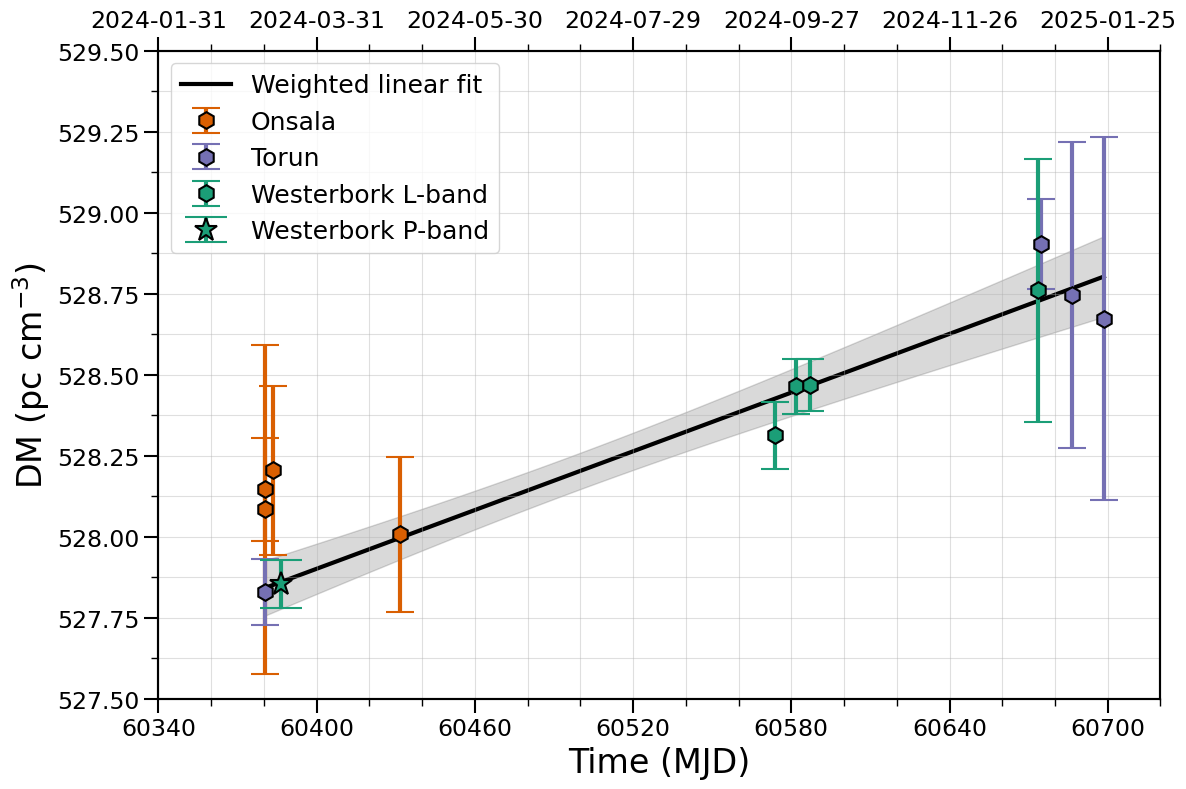

In [5]:
#Simple code copied from GPT -- need to go through the full code to verify what is happeing and if it's correct
def dm_time_panel(dm_df, dm_color="#1b9e77"):
    """
    Plot DM vs Time with a weighted linear fit and uncertainty band.

    Parameters
    ----------
    dm_df : pd.DataFrame
        Must contain columns: ['MJD', 'DM', 'DM_err', 'Telescope']
    """

    fig, ax = plt.subplots(figsize=(12, 8))

    # --- Shared x-limits and ticks ---
    xlim = (60340, 60720)
    xticks_major = np.arange(60340, 60720, 60)

    for tel in dm_df["Telescope"].unique():
        subset = dm_df[dm_df["Telescope"] == tel]
        color = telescope_colors.get(tel, "#000000")
    
        normal = subset[~subset["is_pband"]]
        pband  = subset[subset["is_pband"]]

        if not normal.empty:
            ax.errorbar(
                normal["MJD"], normal["DM"], yerr=normal["DM_err"],
                fmt='h', color=color, ecolor=color,
                elinewidth=3, capsize=10, capthick=3,
                alpha=1.0, zorder=2, label = f"{tel} L-band" if tel == "Westerbork" else tel, markersize=12,
                markeredgecolor='black', markeredgewidth=1.5,
            )
    
        if not pband.empty:
            ax.errorbar(
                pband["MJD"], pband["DM"], yerr=pband["DM_err"],
                fmt='*', color=color, ecolor=color,
                elinewidth=3, capsize=15, capthick=3,
                alpha=1.0, zorder=2, label=f"{tel} P-band", markersize=17,
                markeredgecolor='black', markeredgewidth=1.5,
            )
        
    # # --- Plot each telescope separately ---
    # for tel in dm_df["Telescope"].unique():
    #     subset = dm_df[dm_df["Telescope"] == tel]
    #     color = telescope_colors.get(tel, "#000000")

    #     ax.errorbar(
    #         subset["MJD"], subset["DM"], yerr=subset["DM_err"],
    #         fmt='h', color=color, ecolor=color,
    #         elinewidth=3, capsize=10, capthick=3,
    #         alpha=1.0, zorder=2, label=tel, markersize=12,
    #         markeredgecolor='black',  
    #         markeredgewidth=1.5,  
    #     )

    # =========================
    # Weighted linear fit
    # =========================
    x = dm_df["MJD"].values
    y = dm_df["DM"].values
    yerr = dm_df["DM_err"].values

    w = 1 / yerr**2

    # Center time for numerical stability
    x0 = x.mean()
    x_centered = x - x0

    p, cov = np.polyfit(x_centered, y, deg=1, w=w, cov=True)
    a, b = p
    a_err, b_err = np.sqrt(np.diag(cov))

    print(f"Slope = {a:.4e} ± {a_err:.4e} pc cm^-3 / day")
    print(f"Slope = {a*365.25:.4e} ± {a_err*365.25:.4e} pc cm^-3 / year")
    print(f"Delta DM over 318 days = {a*318:.4f} ± {a_err*318:.4f} pc cm^-3")
    
    # =========================
    # Fit line + uncertainty
    # =========================
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = a * (x_fit - x0) + b

    # Uncertainty propagation
    y_fit_err = np.sqrt(
        (x_fit - x0)**2 * cov[0, 0] +
        cov[1, 1] +
        2 * (x_fit - x0) * cov[0, 1]
    )

    # Plot fit
    n_sigma = 3
    ax.plot(x_fit, y_fit, color="black", lw=3, zorder=0, label=rf"Weighted linear fit")
    ax.fill_between(
        x_fit,
        y_fit - n_sigma * y_fit_err,
        y_fit + n_sigma * y_fit_err,
        color="black",
        alpha=0.15,   # slightly lighter looks nicer for 3σ
        zorder=1
    )

    # =========================
    # Axes formatting
    # =========================
    ax.set_ylabel(r'DM (pc cm$^{-3}$)', size=24)
    ax.set_xlabel('Time (MJD)', size=24)
    ax.set_xlim(xlim)
    ax.set_ylim(527.5, 529.5)
    ax.set_xticks(xticks_major)

    # Top axis for ISO dates
    ax_top = ax.twiny()
    ax_top.set_xlim(xlim)
    ax_top.set_xticks(xticks_major)
    ax_top.set_xticklabels(
        Time(xticks_major, format='mjd').to_value('iso', subfmt='date'),
        rotation=0, ha='center', fontsize=14
    )

    # Styling
    for axx in [ax, ax_top]:
        for side in ['top', 'bottom', 'left', 'right']:
            axx.spines[side].set_linewidth(1.5)
        axx.tick_params(axis='both', which='major', labelsize=17, width=1.5, length=10)
        axx.tick_params(axis='both', which='minor', labelsize=17, width=1, length=5)
        axx.xaxis.set_minor_locator(ticker.MultipleLocator(20.0))

    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))

    ax.grid(which="both", alpha=0.4)
    ax.legend(loc="upper left", fontsize=18, fancybox=True)
    fig.tight_layout()

    plot_name = f"dm_evolution_V2"
    fig.savefig(plot_name + ".pdf", dpi=300, bbox_inches='tight')
    fig.savefig(plot_name + ".png", facecolor='white', \
                transparent=False, format = 'png',bbox_inches='tight', dpi=300)

    plt.show()


# --- DM Data ---
# --- Row-wise, human-readable input ---
dm_data = """

60380.45214,528.146,0.160,Onsala,p47024_24,B63-o8

60380.27609,528.085,0.508,Onsala,p47024_8,B57-o8
60383.26844,528.205,0.260,Onsala,p47027_10,B102-o8
60431.43777,528.007,0.240,Onsala,p47064_38,B125-o8

60573.92099,528.313,0.103,Westerbork,p55084_34,B135-wb
60581.87250,528.464,0.086,Westerbork,p55092_32,b136-wb
60586.95299,528.468,0.081,Westerbork,p55097_41,B137-wb-Stroop
60673.60990,528.761,0.406,Westerbork,p55173_40,B140-wb

60380.43194,527.830,0.102,Torun,rn1l10_11,b60-tr
60674.67263,528.904,0.139,Torun,rn1l62_14,B141-tr
60686.62063,528.746,0.471,Torun,rn1l67_14,B158-tr
60698.53842,528.673,0.560,Torun,rn1l70_07,B163-tr

60386.37677,527.854,0.075,Westerbork,p47030_21,B105-wb
"""

#60581.87250,528.0,2.0,Westerbork #p55092_32 - B136-Wb


# --- Parse into DataFrame ---
dm_df = pd.read_csv(StringIO(dm_data), header=None, names=["MJD", "DM", "DM_err", "Telescope","project","burst_id"], comment="#")
dm_df["is_pband"] = dm_df["MJD"] == 60386.37677
dm_df["Telescope"] = dm_df["Telescope"].astype(str).str.strip()
dm_df = dm_df.sort_values(by=["MJD"])
display(dm_df)
dm_df.to_csv("dm_evolving_data.csv", index=False)
# Plot
dm_time_panel(dm_df)

,MJD,DM,DM_err,Telescope,project,burst_id,is_pband
1,60380.27609,528.085,0.508,Onsala,p47024_8,B57-o8,False
8,60380.43194,527.830,0.102,Torun,rn1l10_11,b60-tr,False
0,60380.45214,528.146,0.160,Onsala,p47024_24,B63-o8,False
2,60383.26844,528.205,0.260,Onsala,p47027_10,B102-o8,False
12,60386.37677,527.854,0.075,Westerbork,p47030_21,B105-wb,True
3,60431.43777,528.007,0.240,Onsala,p47064_38,B125-o8,False
4,60573.92099,528.313,0.103,Westerbork,p55084_34,B135-wb,False
5,60581.87250,528.464,0.086,Westerbork,p55092_32,b136-wb,False
6,60586.95299,528.468,0.081,Westerbork,p55097_41,B137-wb-Stroop,False
7,60673.60990,528.761,0.406,Westerbork,p55173_40,B140-wb,False


Slope = 3.0212e-03 ± 1.8379e-04 pc cm^-3 / day
Slope = 1.1035e+00 ± 6.7129e-02 pc cm^-3 / year
Delta DM over 318 days = 0.9607 ± 0.0584 pc cm^-3
Weighted constant model = 528.2353 pc cm^-3


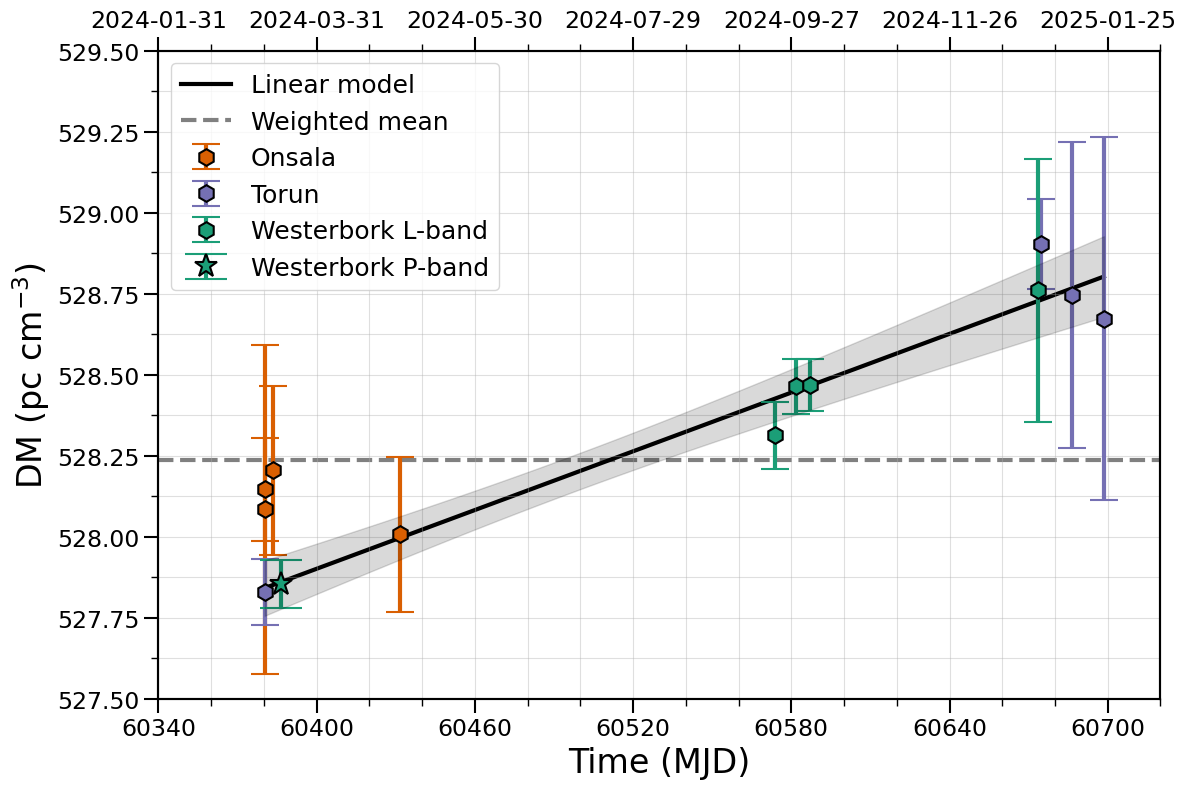

In [6]:
def dm_time_panel(dm_df, dm_color="#1b9e77"):
    """
    Plot DM vs Time with a weighted linear fit and uncertainty band,
    plus a weighted constant (MLE) model line.

    Parameters
    ----------
    dm_df : pd.DataFrame
        Must contain columns: ['MJD', 'DM', 'DM_err', 'Telescope']
    """

    fig, ax = plt.subplots(figsize=(12, 8))

    # --- Shared x-limits and ticks ---
    xlim = (60340, 60720)
    xticks_major = np.arange(60340, 60720, 60)

    for tel in dm_df["Telescope"].unique():
        subset = dm_df[dm_df["Telescope"] == tel]
        color = telescope_colors.get(tel, "#000000")
    
        normal = subset[~subset["is_pband"]]
        pband  = subset[subset["is_pband"]]

        if not normal.empty:
            ax.errorbar(
                normal["MJD"], normal["DM"], yerr=normal["DM_err"],
                fmt='h', color=color, ecolor=color,
                elinewidth=3, capsize=10, capthick=3,
                alpha=1.0, zorder=2, label=f"{tel} L-band" if tel == "Westerbork" else tel, markersize=12,
                markeredgecolor='black', markeredgewidth=1.5,
            )
    
        if not pband.empty:
            ax.errorbar(
                pband["MJD"], pband["DM"], yerr=pband["DM_err"],
                fmt='*', color=color, ecolor=color,
                elinewidth=3, capsize=15, capthick=3,
                alpha=1.0, zorder=2, label=f"{tel} P-band", markersize=17,
                markeredgecolor='black', markeredgewidth=1.5,
            )

    # =========================
    # Weighted linear fit
    # =========================
    x = dm_df["MJD"].values
    y = dm_df["DM"].values
    yerr = dm_df["DM_err"].values

    w = 1 / yerr**2

    # Center time for numerical stability
    x0 = x.mean()
    x_centered = x - x0

    p, cov = np.polyfit(x_centered, y, deg=1, w=w, cov=True)
    a, b = p
    a_err, b_err = np.sqrt(np.diag(cov))

    print(f"Slope = {a:.4e} ± {a_err:.4e} pc cm^-3 / day")
    print(f"Slope = {a*365.25:.4e} ± {a_err*365.25:.4e} pc cm^-3 / year")
    print(f"Delta DM over 318 days = {a*318:.4f} ± {a_err*318:.4f} pc cm^-3")

    # =========================
    # Weighted constant model
    # =========================
    m_const = mle_constant(y, yerr)
    print(f"Weighted constant model = {m_const:.4f} pc cm^-3")

    # =========================
    # Fit line + uncertainty
    # =========================
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = a * (x_fit - x0) + b

    # Uncertainty propagation
    y_fit_err = np.sqrt(
        (x_fit - x0)**2 * cov[0, 0] +
        cov[1, 1] +
        2 * (x_fit - x0) * cov[0, 1]
    )

    # Plot fit
    n_sigma = 3
    ax.plot(x_fit, y_fit, color="black", lw=3, zorder=1, label=f"Linear model")
    ax.fill_between(
        x_fit,
        y_fit - n_sigma * y_fit_err,
        y_fit + n_sigma * y_fit_err,
        color="black",
        alpha=0.15,
        zorder=2
    )

    # Plot constant model
    ax.axhline(m_const, color='grey', linestyle='--', lw=3, zorder=0, label='Weighted mean')

    # =========================
    # Axes formatting
    # =========================
    ax.set_ylabel(r'DM (pc cm$^{-3}$)', size=24)
    ax.set_xlabel('Time (MJD)', size=24)
    ax.set_xlim(xlim)
    ax.set_ylim(527.5, 529.5)
    ax.set_xticks(xticks_major)

    # Top axis for ISO dates
    ax_top = ax.twiny()
    ax_top.set_xlim(xlim)
    ax_top.set_xticks(xticks_major)
    ax_top.set_xticklabels(
        Time(xticks_major, format='mjd').to_value('iso', subfmt='date'),
        rotation=0, ha='center', fontsize=14
    )

    # Styling
    for axx in [ax, ax_top]:
        for side in ['top', 'bottom', 'left', 'right']:
            axx.spines[side].set_linewidth(1.5)
        axx.tick_params(axis='both', which='major', labelsize=17, width=1.5, length=10)
        axx.tick_params(axis='both', which='minor', labelsize=17, width=1, length=5)
        axx.xaxis.set_minor_locator(ticker.MultipleLocator(20.0))

    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))

    ax.grid(which="both", alpha=0.4)
    ax.legend(loc="upper left", fontsize=18, fancybox=True)
    fig.tight_layout()

    plot_name = f"dm_evolution_V2"
    fig.savefig(plot_name + ".pdf", dpi=300, bbox_inches='tight')
    fig.savefig(plot_name + ".png", facecolor='white',
                transparent=False, format='png', bbox_inches='tight', dpi=300)

    plt.show()

# --- DM Data ---
# --- Row-wise, human-readable input ---
dm_data = """

60380.45214,528.146,0.160,Onsala,p47024_24,B63-o8

60380.27609,528.085,0.508,Onsala,p47024_8,B57-o8
60383.26844,528.205,0.260,Onsala,p47027_10,B102-o8
60431.43777,528.007,0.240,Onsala,p47064_38,B125-o8

60573.92099,528.313,0.103,Westerbork,p55084_34,B135-wb
60581.87250,528.464,0.086,Westerbork,p55092_32,b136-wb
60586.95299,528.468,0.081,Westerbork,p55097_41,B137-wb-Stroop
60673.60990,528.761,0.406,Westerbork,p55173_40,B140-wb

60380.43194,527.830,0.102,Torun,rn1l10_11,b60-tr
60674.67263,528.904,0.139,Torun,rn1l62_14,B141-tr
60686.62063,528.746,0.471,Torun,rn1l67_14,B158-tr
60698.53842,528.673,0.560,Torun,rn1l70_07,B163-tr

60386.37677,527.854,0.075,Westerbork,p47030_21,B105-wb
"""

# --- Parse into DataFrame ---
dm_df = pd.read_csv(StringIO(dm_data), header=None, names=["MJD", "DM", "DM_err", "Telescope","project","burst_id"], comment="#")
dm_df["is_pband"] = dm_df["MJD"] == 60386.37677
dm_df["Telescope"] = dm_df["Telescope"].astype(str).str.strip()
dm_df = dm_df.sort_values(by=["MJD"])
display(dm_df)
dm_df.to_csv("dm_evolving_data.csv", index=False)
# Plot
dm_time_panel(dm_df)